# 앱 업데이트 Before/After 평점 분석
**"어떤 종류의 앱 업데이트가 평점을 올리고, 어떤 업데이트가 평점을 내리는가?"**

- 분석 대상: 배달의민족, 쿠팡이츠, 쿠팡, 마켓컬리, 카카오뱅크, 토스
- 데이터: google-play-scraper 리뷰 (앱당 5,000건) + 버전 타임라인
- 업데이트 유형: major(주요개편) / minor(기능추가) / patch(버그픽스)

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path("..").resolve()))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# 한글 폰트 설정 (Windows)
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 120

DATA_DIR = pathlib.Path("../data")

# ── 통합 분석 데이터 로드
df = pd.read_csv(DATA_DIR / "processed/all_apps_analysis.csv", parse_dates=["update_date"])

# 앱 이름 매핑
APP_NAMES = {
    "com.sampleapp":          "배달의민족",
    "com.coupang.mobile.eats":"쿠팡이츠",
    "com.coupang.mobile":     "쿠팡",
    "com.dbs.kurly.m2":       "마켓컬리",
    "com.kakaobank.channel":  "카카오뱅크",
    "viva.republica.toss":    "토스",
}
df["app_name"] = df["app_id"].map(APP_NAMES)

print(f"총 업데이트 분석 건수: {len(df)}")
print(f"\n앱별 건수:")
print(df.groupby("app_name").size().sort_values(ascending=False).to_string())
print(f"\n업데이트 유형 분포:")
print(df["update_type"].value_counts().to_string())

총 업데이트 분석 건수: 528

앱별 건수:
app_name
마켓컬리     181
카카오뱅크     90
쿠팡        87
토스        76
쿠팡이츠      67
배달의민족     27

업데이트 유형 분포:
update_type
minor    242
patch    214
major     72


## 1. 업데이트 유형별 평점 변화 (핵심 가설 검증)

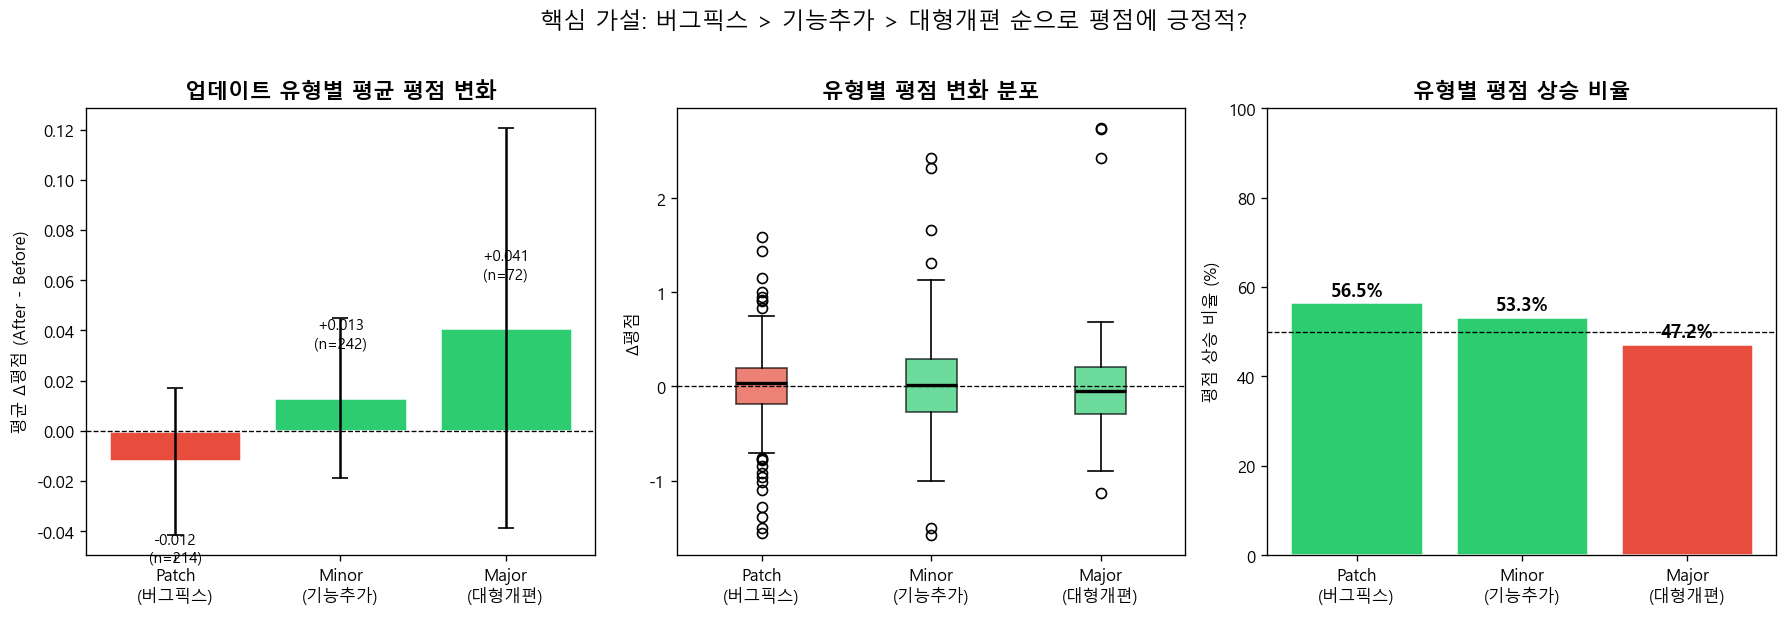

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
update_order = ["patch", "minor", "major"]
update_labels = {"patch": "Patch\n(버그픽스)", "minor": "Minor\n(기능추가)", "major": "Major\n(대형개편)"}
colors = {"positive": "#2ecc71", "negative": "#e74c3c", "neutral": "#95a5a6"}

# ── 1) 유형별 평균 score_delta
type_stats = df.groupby("update_type")["score_delta"].agg(["mean", "std", "count"]).reindex(update_order)
bar_colors = [colors["positive"] if v >= 0 else colors["negative"] for v in type_stats["mean"]]
axes[0].bar([update_labels[u] for u in update_order], type_stats["mean"],
            color=bar_colors, edgecolor="white", linewidth=1.5,
            yerr=type_stats["std"] / np.sqrt(type_stats["count"]), capsize=5)
axes[0].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[0].set_title("업데이트 유형별 평균 평점 변화", fontsize=13, fontweight="bold")
axes[0].set_ylabel("평균 Δ평점 (After - Before)")
for i, (_, row) in enumerate(type_stats.iterrows()):
    axes[0].text(i, row["mean"] + (0.02 if row["mean"] >= 0 else -0.04),
                 f"{row['mean']:+.3f}\n(n={int(row['count'])})",
                 ha="center", fontsize=9)

# ── 2) 유형별 score_delta 분포 (박스플롯)
data_by_type = [df[df["update_type"] == u]["score_delta"].values for u in update_order]
bp = axes[1].boxplot(data_by_type, labels=[update_labels[u] for u in update_order],
                     patch_artist=True, notch=False, medianprops=dict(color="black", linewidth=2))
for patch, u in zip(bp["boxes"], update_order):
    m = df[df["update_type"] == u]["score_delta"].mean()
    patch.set_facecolor(colors["positive"] if m >= 0 else colors["negative"])
    patch.set_alpha(0.7)
axes[1].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[1].set_title("유형별 평점 변화 분포", fontsize=13, fontweight="bold")
axes[1].set_ylabel("Δ평점")

# ── 3) 유형별 "평점 상승" 비율
rise_rate = df.groupby("update_type").apply(
    lambda x: (x["score_delta"] > 0).mean() * 100
).reindex(update_order)
bar_colors2 = [colors["positive"] if v >= 50 else colors["negative"] for v in rise_rate]
axes[2].bar([update_labels[u] for u in update_order], rise_rate,
            color=bar_colors2, edgecolor="white", linewidth=1.5)
axes[2].axhline(50, color="black", linewidth=0.8, linestyle="--", label="50% 기준선")
axes[2].set_title("유형별 평점 상승 비율", fontsize=13, fontweight="bold")
axes[2].set_ylabel("평점 상승 비율 (%)")
axes[2].set_ylim(0, 100)
for i, v in enumerate(rise_rate):
    axes[2].text(i, v + 1.5, f"{v:.1f}%", ha="center", fontsize=11, fontweight="bold")

plt.suptitle("핵심 가설: 버그픽스 > 기능추가 > 대형개편 순으로 평점에 긍정적?",
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("../data/processed/fig1_update_type_delta.png", bbox_inches="tight", dpi=150)
plt.show()

## 2. 앱별 업데이트 후 평점 변화 추이

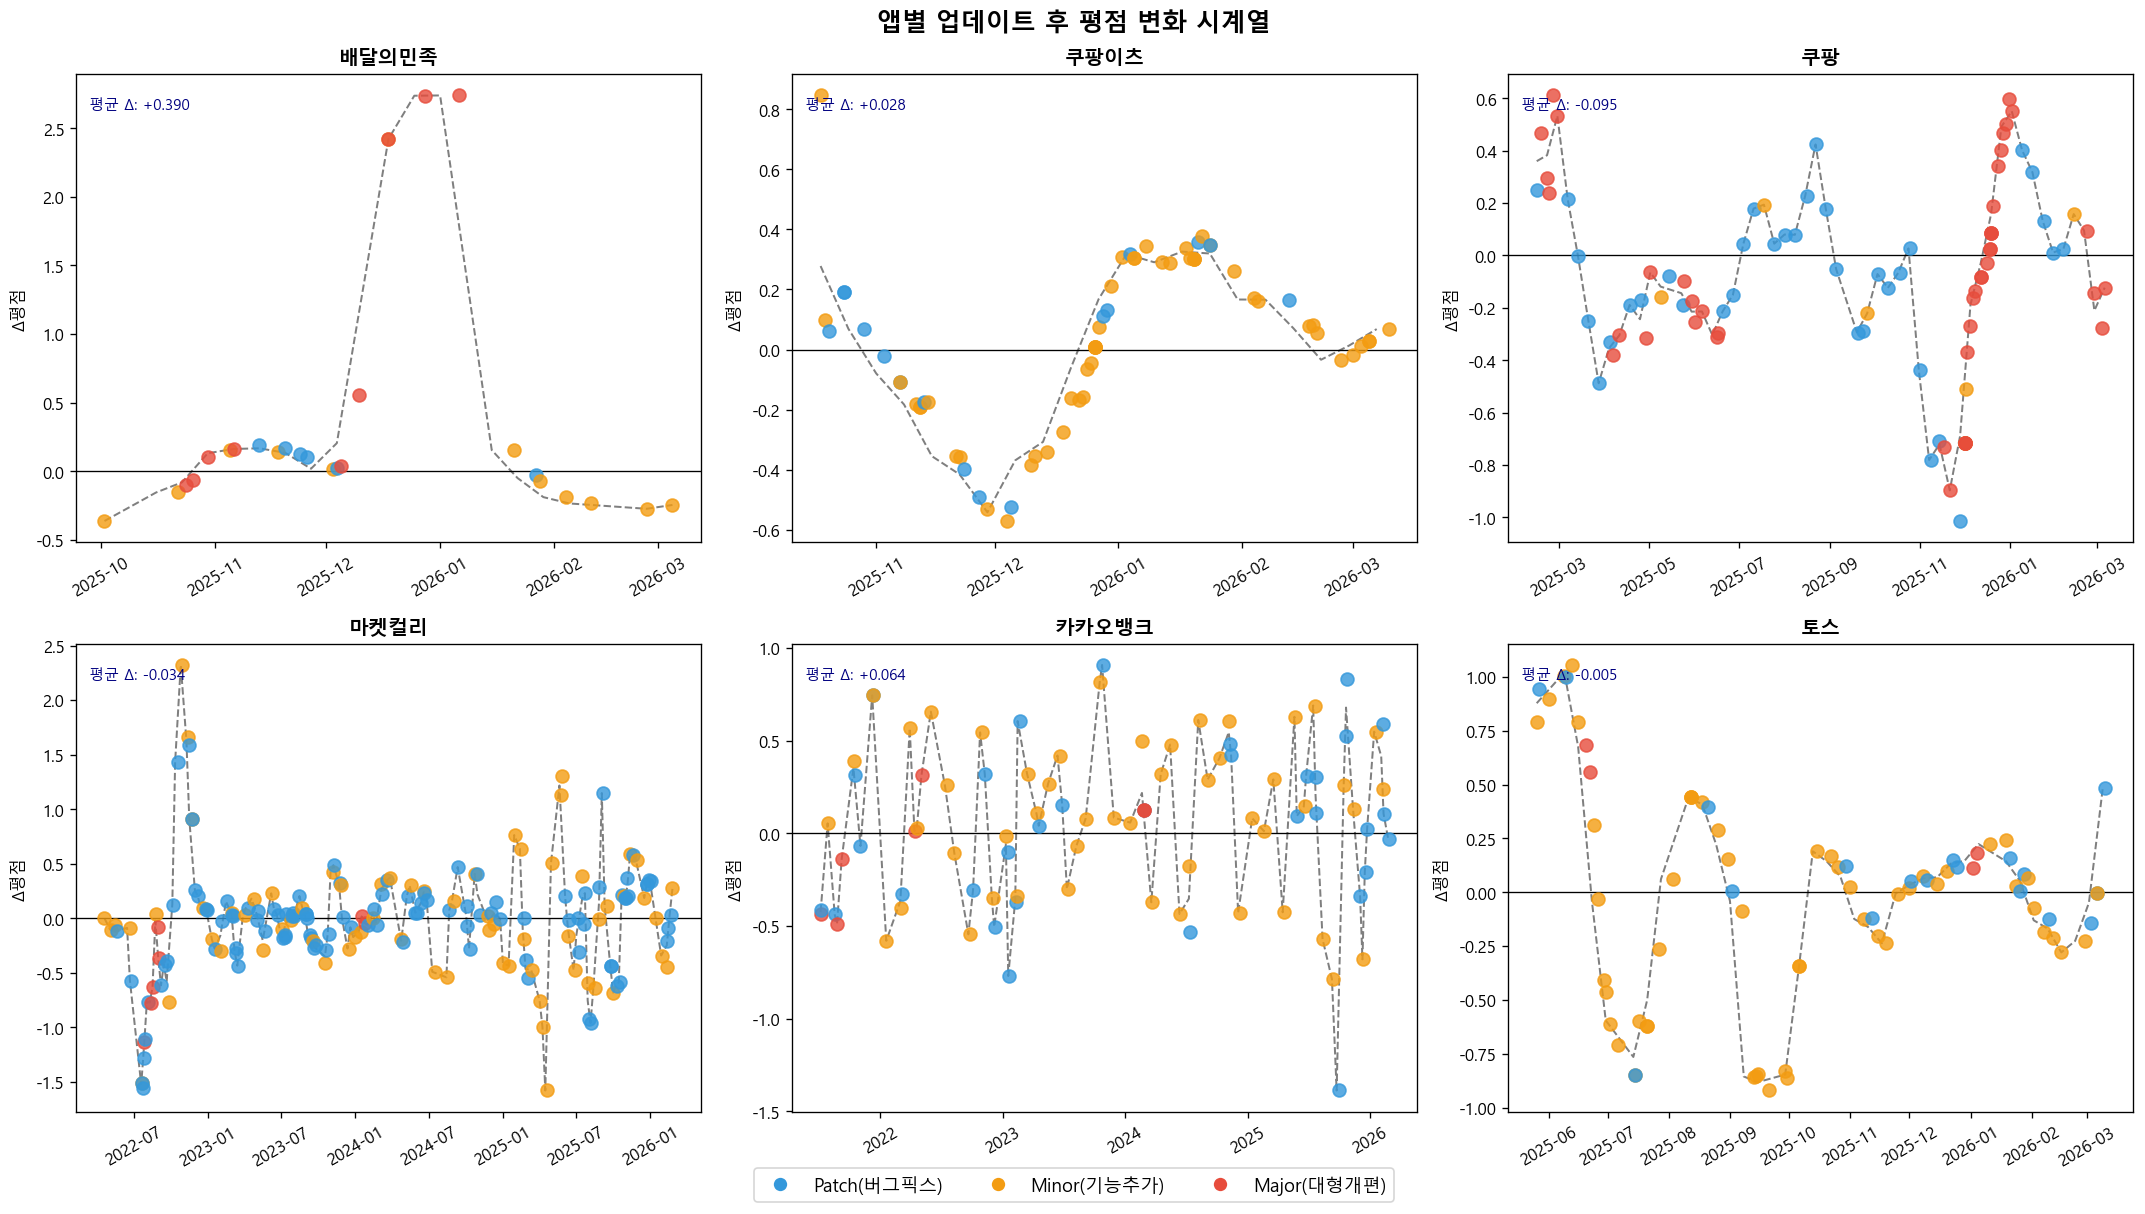

In [3]:
app_order = list(APP_NAMES.values())
type_colors = {"patch": "#3498db", "minor": "#f39c12", "major": "#e74c3c"}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, app_id in enumerate(APP_NAMES.keys()):
    ax = axes[idx]
    sub = df[df["app_id"] == app_id].sort_values("update_date").copy()
    app_name = APP_NAMES[app_id]

    for _, row in sub.iterrows():
        ax.scatter(row["update_date"], row["score_delta"],
                   color=type_colors[row["update_type"]],
                   s=60, alpha=0.8, zorder=3)

    # 7일 이동 평균 (날짜 기준 리샘플)
    sub_ts = sub.set_index("update_date")["score_delta"].resample("7D").mean().dropna()
    if len(sub_ts) > 1:
        ax.plot(sub_ts.index, sub_ts.values, color="black", linewidth=1.2,
                alpha=0.5, linestyle="--", label="7일 이동평균")

    ax.axhline(0, color="black", linewidth=0.8, linestyle="-")
    ax.set_title(app_name, fontsize=12, fontweight="bold")
    ax.set_ylabel("Δ평점")
    ax.tick_params(axis="x", rotation=30)

    # 평균 표시
    mean_delta = sub["score_delta"].mean()
    ax.text(0.02, 0.95, f"평균 Δ: {mean_delta:+.3f}", transform=ax.transAxes,
            fontsize=9, va="top", color="navy")

# 범례
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0],[0], marker="o", color="w", markerfacecolor=c, markersize=9, label=t)
    for t, c in type_colors.items()
]
fig.legend(handles=legend_elements, loc="lower center", ncol=3,
           labels=["Patch(버그픽스)", "Minor(기능추가)", "Major(대형개편)"],
           fontsize=11, bbox_to_anchor=(0.5, -0.02))

plt.suptitle("앱별 업데이트 후 평점 변화 시계열", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("../data/processed/fig2_timeseries.png", bbox_inches="tight", dpi=150)
plt.show()

## 3. 1점 리뷰 비율 변화 (부정 반응 집중 분석)

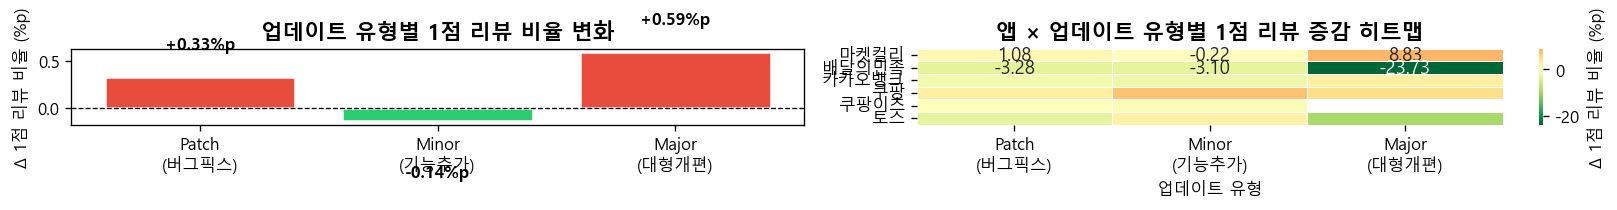

In [4]:
df["star1_delta"] = df["after_1star_pct"] - df["before_1star_pct"]
df["star5_delta"] = df["after_5star_pct"] - df["before_5star_pct"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── 1) 유형별 1점 리뷰 증감
type_1star = df.groupby("update_type")["star1_delta"].mean().reindex(update_order)
bar_colors3 = [colors["negative"] if v > 0 else colors["positive"] for v in type_1star]
axes[0].bar([update_labels[u] for u in update_order], type_1star,
            color=bar_colors3, edgecolor="white", linewidth=1.5)
axes[0].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[0].set_title("업데이트 유형별 1점 리뷰 비율 변화", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Δ 1점 리뷰 비율 (%p)")
for i, v in enumerate(type_1star):
    axes[0].text(i, v + (0.3 if v >= 0 else -0.6), f"{v:+.2f}%p",
                 ha="center", fontsize=10, fontweight="bold")

# ── 2) 앱별 업데이트 후 1점 리뷰 변화 히트맵
heatmap_data = df.pivot_table(
    index="app_name", columns="update_type", values="star1_delta", aggfunc="mean"
)[update_order]
heatmap_data.index = [APP_NAMES.get(i, i) for i in heatmap_data.index]

sns.heatmap(heatmap_data, ax=axes[1], annot=True, fmt=".2f", cmap="RdYlGn_r",
            center=0, linewidths=0.5, cbar_kws={"label": "Δ 1점 리뷰 비율 (%p)"},
            annot_kws={"size": 11})
axes[1].set_title("앱 × 업데이트 유형별 1점 리뷰 증감 히트맵", fontsize=13, fontweight="bold")
axes[1].set_xlabel("업데이트 유형")
axes[1].set_ylabel("")
axes[1].set_xticklabels(["Patch\n(버그픽스)", "Minor\n(기능추가)", "Major\n(대형개편)"])

plt.tight_layout()
plt.savefig("../data/processed/fig3_1star_heatmap.png", bbox_inches="tight", dpi=150)
plt.show()

## 4. 비즈니스 인사이트 요약

In [5]:
print("=" * 60)
print("비즈니스 인사이트 요약")
print("=" * 60)

for u in update_order:
    sub = df[df["update_type"] == u]
    mean_d  = sub["score_delta"].mean()
    rise_r  = (sub["score_delta"] > 0).mean() * 100
    mean_1d = sub["star1_delta"].mean()
    label   = {"patch": "버그픽스", "minor": "기능추가", "major": "대형개편"}[u]
    print(f"\n[{label.upper()} ({u})]  n={len(sub)}")
    print(f"  평균 평점 변화:   {mean_d:+.3f}점")
    print(f"  평점 상승 비율:   {rise_r:.1f}%")
    print(f"  1점 리뷰 변화:    {mean_1d:+.2f}%p")

print("\n" + "=" * 60)
print("앱별 평균 평점 변화")
print("=" * 60)
app_summary = df.groupby("app_name").agg(
    mean_delta=("score_delta", "mean"),
    updates=("score_delta", "count"),
    rise_rate=("score_delta", lambda x: (x > 0).mean() * 100)
).sort_values("mean_delta", ascending=False)
print(app_summary.to_string())

print("\n" + "=" * 60)
print("최악의 업데이트 TOP 5 (평점 급락)")
print("=" * 60)
worst = df.nsmallest(5, "score_delta")[["app_name", "version", "update_type", "update_date", "score_delta", "star1_delta"]]
print(worst.to_string(index=False))

print("\n" + "=" * 60)
print("최고의 업데이트 TOP 5 (평점 급등)")
print("=" * 60)
best = df.nlargest(5, "score_delta")[["app_name", "version", "update_type", "update_date", "score_delta", "star1_delta"]]
print(best.to_string(index=False))

비즈니스 인사이트 요약

[버그픽스 (patch)]  n=214
  평균 평점 변화:   -0.012점
  평점 상승 비율:   56.5%
  1점 리뷰 변화:    +0.33%p

[기능추가 (minor)]  n=242
  평균 평점 변화:   +0.013점
  평점 상승 비율:   53.3%
  1점 리뷰 변화:    -0.14%p

[대형개편 (major)]  n=72
  평균 평점 변화:   +0.041점
  평점 상승 비율:   47.2%
  1점 리뷰 변화:    +0.59%p

앱별 평균 평점 변화
          mean_delta  updates  rise_rate
app_name                                
배달의민족       0.390407       27  62.962963
카카오뱅크       0.064411       90  62.222222
쿠팡이츠        0.028299       67  61.194030
토스         -0.005316       76  55.263158
마켓컬리       -0.033674      181  50.828729
쿠팡         -0.094506       87  41.379310

최악의 업데이트 TOP 5 (평점 급락)
app_name version update_type update_date  score_delta  star1_delta
    마켓컬리  3.49.0       minor  2025-04-19       -1.578         34.8
    마켓컬리  2.41.2       patch  2022-07-24       -1.559         29.9
    마켓컬리  2.41.0       minor  2022-07-23       -1.507         29.1
    마켓컬리  2.41.1       patch  2022-07-23       -1.507         29.1
   카카오뱅크  2.52.1       p